# Import Libraries|

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image   
print("All Libraries Loaded")

All Libraries Loaded


# Path Loading

In [3]:
DATASET_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation"
TRAIN_IMAGE_DIR = os.path.join(DATASET_PATH, "train", "images")
TRAIN_MASK_DIR = os.path.join(DATASET_PATH, "train", "masks")

TEST_IMAGE_DIR = os.path.join(DATASET_PATH, "test", "images")
TEST_MASK_DIR = os.path.join(DATASET_PATH, "test", "masks")

print("Dataset path:", DATASET_PATH)

Dataset path: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation


# Count actual images and masks

In [4]:
# =========================
# Supported image formats
# =========================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


# =========================
# Function to count files
# =========================

def count_images(folder):

    if not os.path.exists(folder):
        return 0

    files = os.listdir(folder)

    image_files = [
        file for file in files
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    return np.size(image_files)


# =========================
# Count Train
# =========================

train_images = count_images(TRAIN_IMAGE_DIR)
train_masks = count_images(TRAIN_MASK_DIR)


# =========================
# Count Test
# =========================

test_images = count_images(TEST_IMAGE_DIR)
test_masks = count_images(TEST_MASK_DIR)


# =========================
# Print Results
# =========================

print("SEGMENTATION DATASET DISTRIBUTION")
print("----------------------------------")

print("Train Images :", train_images)
print("Train Masks  :", train_masks)

print("Test Images  :", test_images)
print("Test Masks   :", test_masks)

print("----------------------------------")

print("Total Images :", train_images + test_images)
print("Total Masks  :", train_masks + test_masks)

SEGMENTATION DATASET DISTRIBUTION
----------------------------------
Train Images : 3933
Train Masks  : 3933
Test Images  : 860
Test Masks   : 860
----------------------------------
Total Images : 4793
Total Masks  : 4793


# Pandas Table

In [5]:
# =========================
# Create DataFrame
# =========================

data = [
    ["Train", train_images, train_masks],
    ["Test", test_images, test_masks],
    [
        "Total",
        train_images + test_images,
        train_masks + test_masks
    ]
]

df = pd.DataFrame(
    data,
    columns=[
        "Dataset Split",
        "MRI Images",
        "Segmentation Masks"
    ]
)

display(df)

,Dataset Split,MRI Images,Segmentation Masks
0,Train,3933,3933
1,Test,860,860
2,Total,4793,4793


# Images masks matching

In [6]:
# =========================
# Check image-mask filenames
# =========================

def get_image_names(folder):

    if not os.path.exists(folder):
        return []

    files = os.listdir(folder)

    return sorted([
        os.path.splitext(file)[0]
        for file in files
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ])


train_image_names = get_image_names(TRAIN_IMAGE_DIR)
train_mask_names = get_image_names(TRAIN_MASK_DIR)

test_image_names = get_image_names(TEST_IMAGE_DIR)
test_mask_names = get_image_names(TEST_MASK_DIR)


# =========================
# Compare
# =========================

train_image_set = set(train_image_names)
train_mask_set = set(train_mask_names)

test_image_set = set(test_image_names)
test_mask_set = set(test_mask_names)


train_missing_masks = train_image_set - train_mask_set
train_missing_images = train_mask_set - train_image_set

test_missing_masks = test_image_set - test_mask_set
test_missing_images = test_mask_set - test_image_set


print("TRAIN")
print("-----")
print("Images:", len(train_image_names))
print("Masks :", len(train_mask_names))
print("Missing masks:", len(train_missing_masks))
print("Missing images:", len(train_missing_images))


print("\nTEST")
print("----")
print("Images:", len(test_image_names))
print("Masks :", len(test_mask_names))
print("Missing masks:", len(test_missing_masks))
print("Missing images:", len(test_missing_images))

TRAIN
-----
Images: 3933
Masks : 3933
Missing masks: 0
Missing images: 0

TEST
----
Images: 860
Masks : 860
Missing masks: 0
Missing images: 0


# Distribution Table

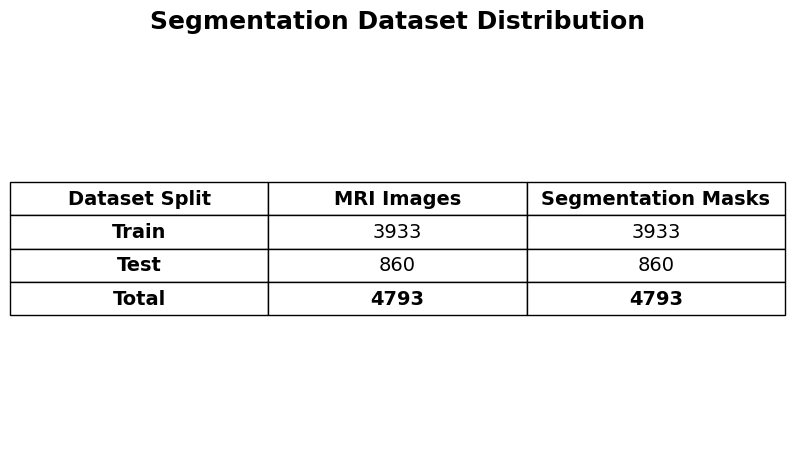

In [7]:
# =========================
# Create Table Image
# =========================

fig, ax = plt.subplots(figsize=(10, 5))

ax.axis("off")


# Create table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)


# Font
table.auto_set_font_size(False)
table.set_fontsize(14)


# Increase row height
table.scale(1, 2)


# =========================
# Bold Header
# =========================

for col in range(len(df.columns)):
    table[0, col].set_text_props(weight="bold")


# =========================
# Bold First Column
# =========================

for row in range(1, len(df) + 1):
    table[row, 0].set_text_props(weight="bold")


# =========================
# Bold Total Row
# =========================

total_row = len(df)

for col in range(len(df.columns)):
    table[total_row, col].set_text_props(weight="bold")


# =========================
# Title
# =========================

plt.title(
    "Segmentation Dataset Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)


# =========================
# Save Image
# =========================

plt.savefig(
    "segmentation_dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

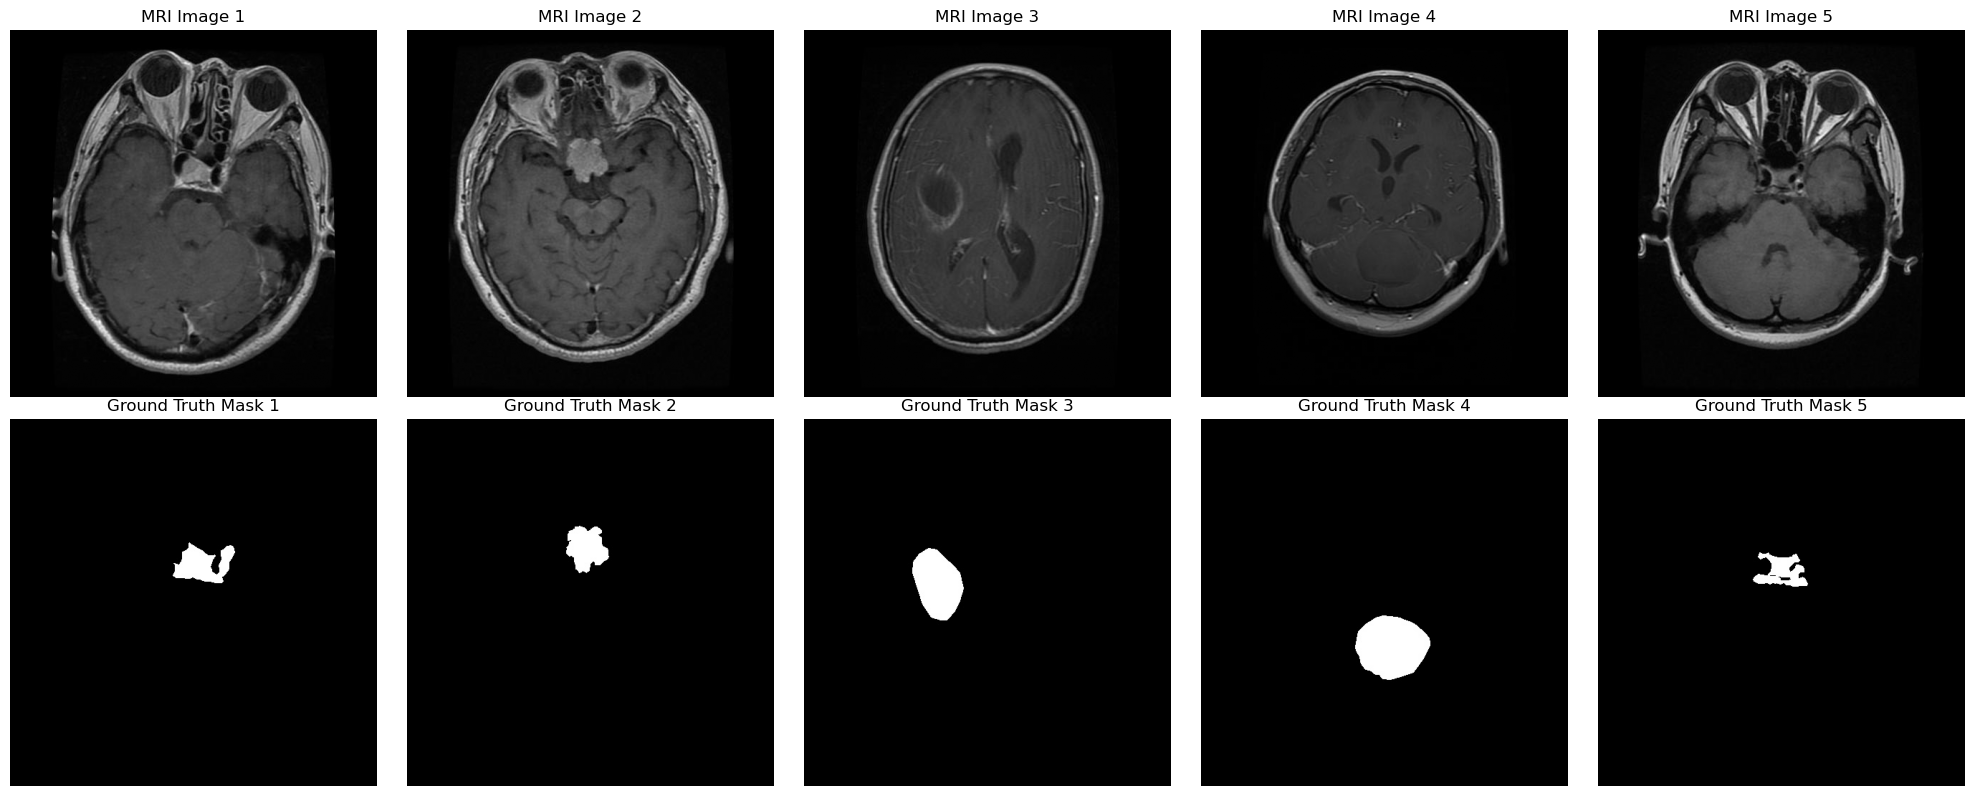

In [17]:
DATASET_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation"

IMAGE_DIR = os.path.join(DATASET_PATH, "train", "images")
MASK_DIR = os.path.join(DATASET_PATH, "train", "masks")


# ==========================================
# Get image files
# ==========================================

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

# Select random images
num_samples = 5

random_files = random.sample(
    image_files,
    min(num_samples, len(image_files))
)


# ==========================================
# Display images and masks horizontally
# ==========================================

fig, axes = plt.subplots(
    2,
    num_samples,
    figsize=(4 * num_samples, 8)
)

# Handle case when num_samples = 1
if num_samples == 1:
    axes = np.expand_dims(axes, axis=1)


for i, image_file in enumerate(random_files):

    # Image filename without extension
    image_name = os.path.splitext(image_file)[0]

    # Find corresponding mask
    mask_file = None

    for file in os.listdir(MASK_DIR):

        mask_name = os.path.splitext(file)[0]

        if mask_name == image_name:
            mask_file = file
            break

    # If corresponding mask does not exist
    if mask_file is None:
        print("Mask not found for:", image_file)
        continue

    # Full paths
    image_path = os.path.join(IMAGE_DIR, image_file)
    mask_path = os.path.join(MASK_DIR, mask_file)

    # Load image
    image = np.array(Image.open(image_path).convert("L"))

    # Load mask
    mask = np.array(Image.open(mask_path).convert("L"))

    # ==========================================
    # MRI Image
    # ==========================================

    axes[0, i].imshow(image, cmap="gray")
    axes[0, i].set_title(f"MRI Image {i + 1}")
    axes[0, i].axis("off")

    # ==========================================
    # Ground Truth Mask
    # ==========================================

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title(f"Ground Truth Mask {i + 1}")
    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

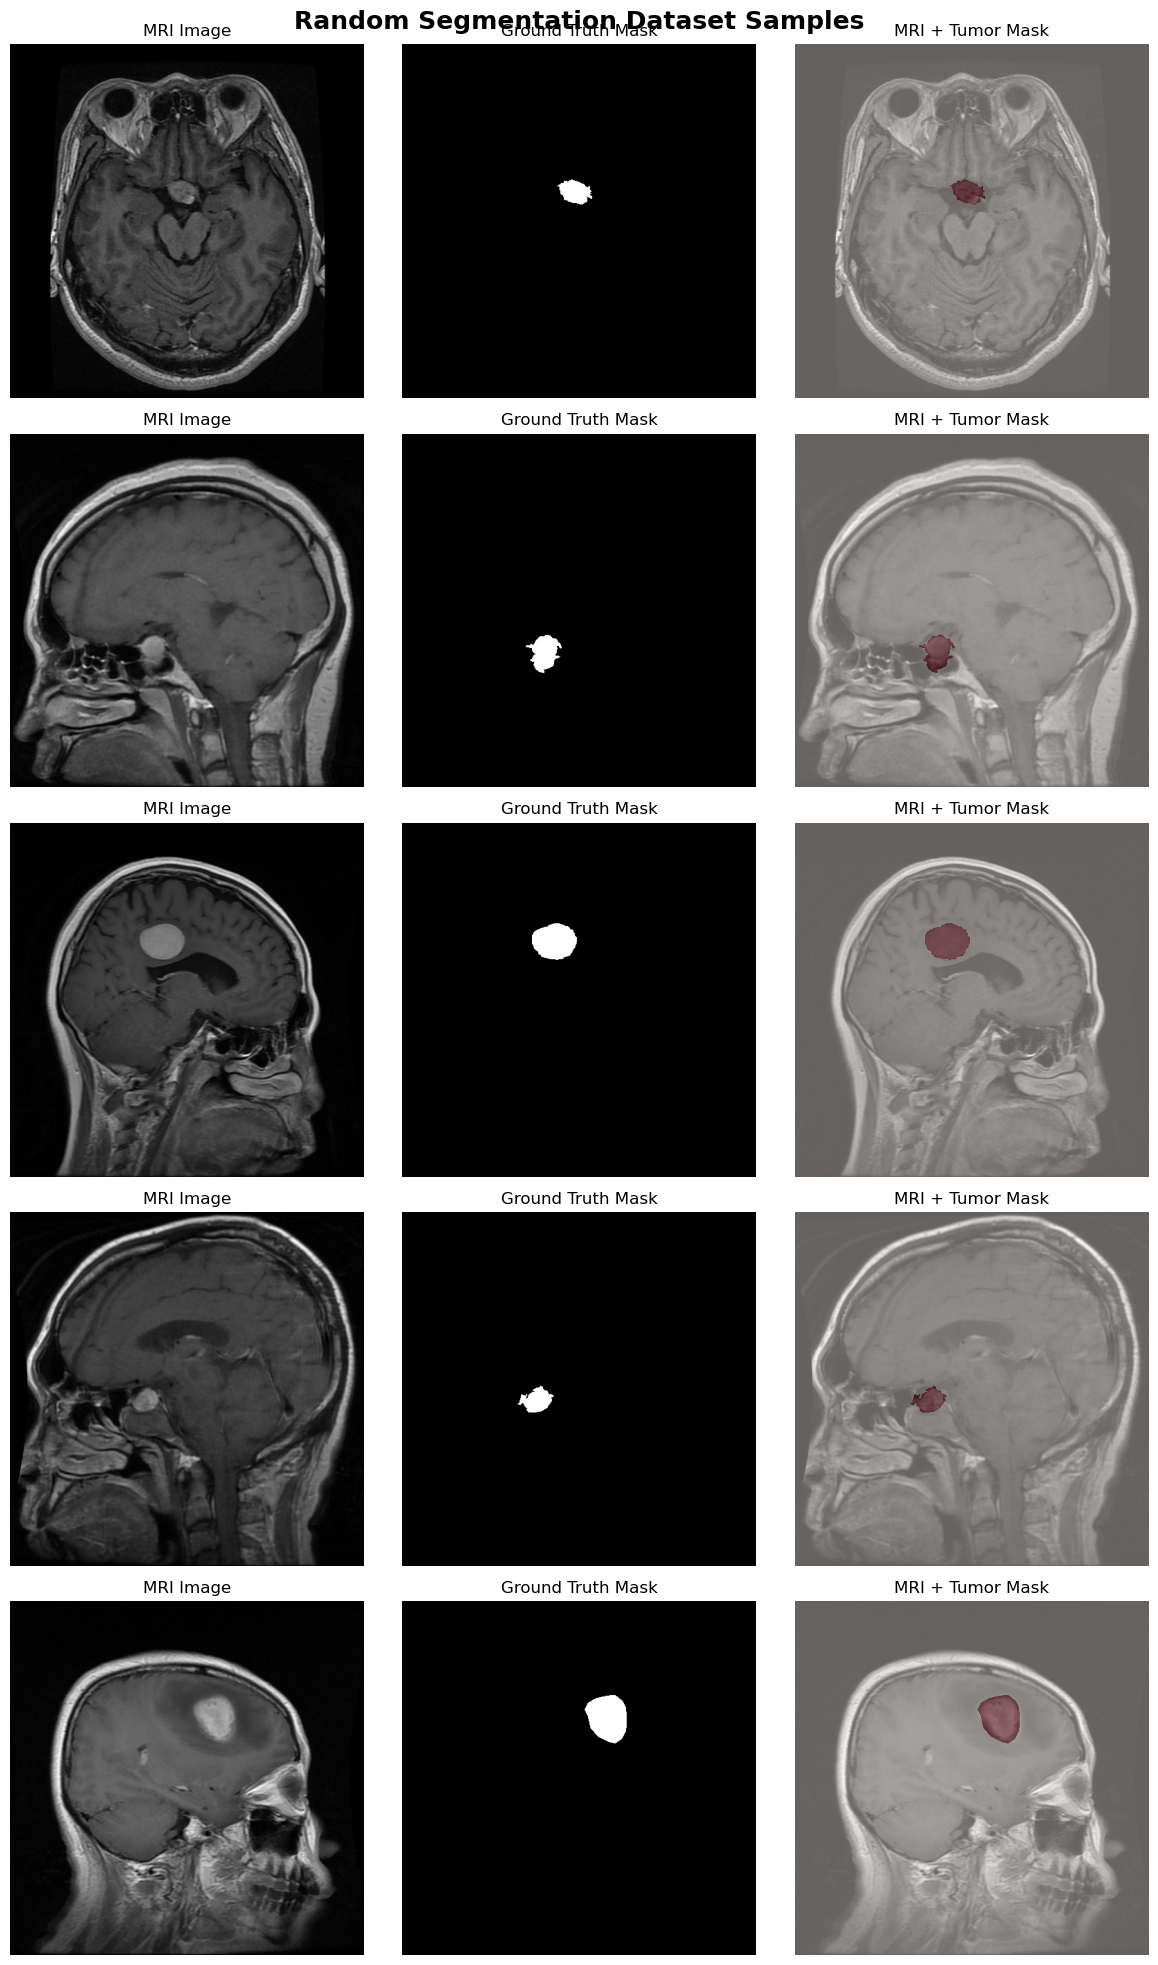

In [16]:


IMAGE_DIR = os.path.join(DATASET_PATH, "train", "images")
MASK_DIR = os.path.join(DATASET_PATH, "train", "masks")

# Get images
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

num_samples = 5

random_files = random.sample(
    image_files,
    min(num_samples, len(image_files))
)

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, image_file in enumerate(random_files):

    image_name = os.path.splitext(image_file)[0]

    # Find matching mask
    mask_file = None

    for file in os.listdir(MASK_DIR):

        if os.path.splitext(file)[0] == image_name:
            mask_file = file
            break

    if mask_file is None:
        print("Mask not found:", image_file)
        continue

    image_path = os.path.join(IMAGE_DIR, image_file)
    mask_path = os.path.join(MASK_DIR, mask_file)

    # Load
    image = np.array(Image.open(image_path).convert("L"))
    mask = np.array(Image.open(mask_path).convert("L"))

    # Display MRI
    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    # Display mask
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    # Display overlay
    axes[i, 2].imshow(image, cmap="gray")
    axes[i, 2].imshow(
        mask,
        cmap="Reds",
        alpha=0.4
    )
    axes[i, 2].set_title("MRI + Tumor Mask")
    axes[i, 2].axis("off")

plt.suptitle(
    "Random Segmentation Dataset Samples",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()